# Семинар 4: выравнивание LLM с помощью обучения с подкреплением по человеческому фидбэку (RLHF)

## Введение

Большие языковые модели умеют много всего, но у них есть одна существенная проблема: уметь ≠ делать так, как мы хотим.  

Модель может писать связно, но:
- не попадать в нужный стиль (слишком нейтрально или слишком эмоционально),
- не соблюдать предпочтения (хочу вежливо / хочу кратко / хочу позитивно),
- иногда читерить цель (делать вид, что хорошо, но по смыслу - пусто).

Тут нам на помощь приходит RLHF - это семейство техник, которые учат модель оптимизировать не метрику "правдоподобия текста", а человеческое предпочтение: какой ответ лучше, какой хуже.

В реальном мире эти предпочтения часто приходят как парные сравнения ("A лучше B") или рейтинги.

### План семинара

Мы пройдем полный  пайплайн "мини-RLHF" на простом и понятном примере. У нас будут следующие этапы работы:

1) **SFT (supervised fine-tuning)**. Сначала слегка адаптируем базовую модель под домен отзывов.

2) *Reward model*. Обучим модель-оценщик, которая на вход получает текст и возвращает одно число - это наш reward, т.е. насколько текст *хороший* по нашему критерию.

3) **Reward-guided generation (best-of-N)**. Без обучения: генерируем N вариантов и выбираем лучший по reward.

4) **PPO (RL fine-tuning)**. Дообучим генератор так, чтобы он сам чаще выдавал ответы с высоким reward, без необходимости перебирать N вариантов.

### Данные

Мы используем датасет [yelp_polarity](https://huggingface.co/datasets/fancyzhx/yelp_polarity). Это короткие и длинные отзывы, и бинарная метка:
- `label = 1` - позитивный отзыв
- `label = 0` - негативный отзыв

Важно: в настоящем RLHF пары предпочтений обычно размечаются людьми. Здесь мы делаем *синтетический human feedback*: строим пары из метки:
- `chosen` = тексты с целевой меткой (например, позитивные),
- `rejected` = тексты с другой меткой.

Это учебный sandbox: логика такая же, как в реальных системах, просто источник предпочтений, скажем, упрощён.

> yelp_polarity - датасет из англоязычных пользовательских отзывов [Yelp](https://www.yelp.ie/) для бинарной классификации тональности: она сформирована по звездам: 1-2 = negative, 3-4 = positive. Домен: отзывы клиентов о бизнесах/сервисах на платформе Yelp. Исходно извлечен из Yelp Dataset Challenge 2015.

### Что будем считать успехом?

По ходу семинара мы будем смотреть на две вещи:

- **Reward от нашей reward-модели** - то, что PPO пытается максимизировать.  
- **Независимую тональность** (отдельный классификатор) - чтобы не получилось самообмана, когда reward растет, а реальная тональность/качество нет.

> И да: высокий reward еще не гарантирует, что текст стал лучше. RLHF умеет находить лазейки.
Поэтому - ручной просмотр примеров и независимая проверка обязательны.

## Setting

In [1]:
# Установка зависимостей
%pip -q install -U transformers datasets accelerate peft trl tokenizers scikit-learn

import os, random, math
import numpy as np
import torch
import transformers
import datasets
import trl

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import pipeline

from datasets import Dataset

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("trl:", trl.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.2 MB/s eta 0:00:00
torch: 2.10.0+cu128
transformers: 5.2.0
datasets: 4.5.0
trl: 0.28.0
device: cuda


## TRL и зачем он/она/они нам?

`trl` (Transformer Reinforcement Learning) - это библиотека от Hugging Face, которая делает RLHF-пайплайны. Вместо того чтобы руками писать RL-цикл, value-head, KL-регуляризацию, логирование и так далее, мы используем уже готовые компоненты:

- **SFTTrainer** - supervised fine-tuning (как обычный `Trainer`, но удобнее для текстового SFT).
- **RewardTrainer** - обучение reward-модели на парных предпочтениях (`chosen` vs `rejected`).
- **PPOTrainer** - RL fine-tuning (PPO) генератора под reward-сигнал.

<img src="https://raw.githubusercontent.com/huggingface/blog/main/assets/133_trl_peft/thumbnail.png" alt="TRL + PEFT" width="900">

> Ключевая идея TRL: модель-генератор и reward-модель - это разные модели и даже разные токенизаторы. Генератор порождает текст, reward-модель его оценивает. PPO обновляет генератор так, чтобы reward рос.

**Value head и зачем он нужен в PPO**

PPO обычно работает с двумя компонентами:
- policy: модель, которая выбирает действия (у нас - токены)
- value function: оценка ожидаемой ценности, т.е. сколько reward мы ожидаем получить.

В TRL генератор для PPO обычно загружается как `AutoModelForCausalLMWithValueHead`:
это обычная языковая модель + маленькая голова, которая предсказывает value. Она нужна, чтобы PPO мог стабильно обновляться и сравнивать результат с ожиданием.


**В PPO есть KL-штраф**

Если просто максимизировать reward, модель быстро сорвется и:
- начнет повторять шаблоны,
- найдет exploit (reward hacking),
- уйдет далеко от исходного языка.

Поэтому PPO почти всегда использует *KL-регуляризацию*: штраф за сильное отклонение от исходной (reference) модели. Интуиция тут такая: мы улучшаемся по reward, но не ломаем язык и стиль полностью.

Небольшая схема для наглядности:

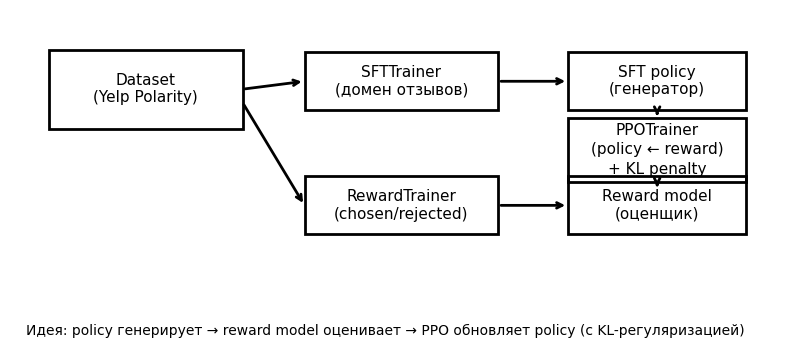

## Конфиг

В этом разделе мы заранее определим все используемые глобальные переменные. Это неплохая практика - чтобы не искать потом по ноутбуку необходимые переменные.

Чтобы ноутбук стабильно работал и на CPU, и на одной GPU, вынесем важные параметры наверх.

- `FAST_RUN=True` - такой демо-режим, мало шагов (быстро).
- `FAST_RUN=False` - более серьёзный прогон (дольше, но эффект заметнее).

In [2]:
FAST_RUN = False  # <-- тут можно переключить

# Датасет
DATASET_NAME = "yelp_polarity"
TEXT_COL = "text"
LABEL_COL = "label"

# Целевая тональность для выравнивания (1 = positive, 0 = negative)
TARGET_LABEL = 1

# Базовая LLM (маленькая и быстрая)
BASE_LM = "distilgpt2"

# Reward model (маленькая, быстрая)
REWARD_MODEL_NAME = "distilbert-base-uncased"

# Независимый оценщик (тональность), чтобы не измерять качество той же reward-моделью
EVAL_SENTIMENT_MODEL = "VictorSanh/roberta-base-finetuned-yelp-polarity"

# Размеры подвыборок
SFT_TRAIN_SIZE = 20_000 if not FAST_RUN else 5_000
RM_TRAIN_SIZE  = 40_000 if not FAST_RUN else 8_000
RM_EVAL_SIZE   = 8_000  if not FAST_RUN else 2_000

# Сколько пар предпочтений сэмплировать на эпоху reward‑обучения
RM_NUM_TRAIN_PAIRS = 80_000 if not FAST_RUN else 15_000
RM_NUM_EVAL_PAIRS  = 10_000 if not FAST_RUN else 3_000

# Ограничения на длину
MAX_SEQ_LEN_LM = 256
MAX_SEQ_LEN_RM = 256

# PPO
PPO_STEPS = 150 if not FAST_RUN else 50
PPO_BATCH_SIZE = 64 if torch.cuda.is_available() else 16
PPO_LEARNING_RATE = 1.41e-5

## Данные

У нашего датасета есть:
- `text`: отзыв
- `label`: 0/1 (отрицательный / положительный)

Давайте сделаем маленькие подвыборки, чтобы быстро обучаться.

> **Важно:** мы делим данные на *непересекающиеся* части для SFT, reward-модели и PPO,
> чтобы избежать data leakage. Каждый этап работает со своим куском данных.

In [3]:
raw = datasets.load_dataset(DATASET_NAME)
train_raw = raw["train"].shuffle(seed=SEED)
test_raw  = raw["test"].shuffle(seed=SEED)

print(train_raw, test_raw)
print("labels:", train_raw.features[LABEL_COL])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 560000
}) Dataset({
    features: ['text', 'label'],
    num_rows: 38000
})
labels: ClassLabel(names=['1', '2'])


In [4]:
PPO_BASE_SIZE = 50_000 if not FAST_RUN else 8_000

sft_end = SFT_TRAIN_SIZE
rm_end = sft_end + RM_TRAIN_SIZE
ppo_end = rm_end + PPO_BASE_SIZE

sft_train = train_raw.select(range(0, sft_end))
rm_base = train_raw.select(range(sft_end, rm_end))
rm_eval_base = test_raw.select(range(RM_EVAL_SIZE))
ppo_base = train_raw.select(range(rm_end, ppo_end))

print(f"SFT: {len(sft_train)} примеров  [0, {sft_end})")
print(f"RM: {len(rm_base)} примеров  [{sft_end}, {rm_end})")
print(f"PPO: {len(ppo_base)} примеров  [{rm_end}, {ppo_end})")

SFT: 20000 примеров  [0, 20000)
RM: 40000 примеров  [20000, 60000)
PPO: 50000 примеров  [60000, 110000)


In [5]:
for i in range(2):
    ex = train_raw[i]
    print("label:", ex[LABEL_COL])
    print(ex[TEXT_COL][:600], "...")
    print("")

label: 1
Decent size, decent selection, decent staff.\n\nI guess that can wholly sum this place up, it's decent.  As with many other stores that are like this, the product rotates depending on what doesn't sale well at other stores.  Can always snag a deal here.  I was able to pick up a pretty sweet Puma jacket for $10, can't beat that, right?\n\nThat being said, there are those times that you may not find anything as well.  So really don't get your hopes up if you are looking for a specific item. ...

label: 0
I have definitely experienced better! Let's see, so I first brought my car here to get the brakes done and they did a pretty good job, although, every time I'm in reverse, my brakes do make a squeaking noise. Not sure what's up with that. Anyway, needless to say, they did a pretty good job on my brakes. \n\nSince my last brake job, they have switched managers and the service has kinda gone down hill. I brought my car in to have the control arm bushings done. They quoted me a lit

## SFT под домен отзывов

PPO обычно стартует не с сырой LLM, а с **SFT‑модели**, которая уже умеет писать тексты в нужном жанре/формате.

Здесь мы сделаем быструю адаптацию `distilgpt2` на подмножестве Yelp - вспомним SFT пайплайн.

SFT обучается на отзывах **обоих классов** (и позитивных, и негативных).
Цель SFT - научить модель писать *в стиле отзывов*, а не смещать тональность. Смещение к целевой тональности - задача reward-модели и PPO.

> Примечание. Если хочется пропустить SFT - можно сразу перейти к reward‑модели и PPO, но генерации будут более разношерстные.

In [6]:
from trl import SFTTrainer, SFTConfig

lm_tokenizer = AutoTokenizer.from_pretrained(BASE_LM)
lm_tokenizer.pad_token = lm_tokenizer.eos_token

lm_model = AutoModelForCausalLM.from_pretrained(BASE_LM)

def formatting_func(example):
    text = example[TEXT_COL].strip().replace("\n", " ")
    return f"Review: {text}\n{lm_tokenizer.eos_token}"

sft_args = SFTConfig(
    output_dir="sft_lm_yelp",
    per_device_train_batch_size=8 if torch.cuda.is_available() else 2,
    learning_rate=2e-5,
    max_steps=300 if not FAST_RUN else 100,
    logging_steps=25,
    disable_tqdm=False,
    log_level="error",
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
    max_length=MAX_SEQ_LEN_LM,
    packing=True,
    packing_strategy="wrapped",
    padding_free=False,
)

sft_trainer = SFTTrainer(
    model=lm_model,
    args=sft_args,
    train_dataset=sft_train,
    processing_class=lm_tokenizer,
    formatting_func=formatting_func,
)

sft_trainer.train()
sft_trainer.save_model("sft_lm_yelp")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Tokenizing train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1183 > 1024). Running this sequence through the model will result in indexing errors


Packing train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Step,Training Loss
25,4.114828
50,3.989627
75,3.938069
100,3.921093
125,3.870334
150,3.860739
175,3.817127
200,3.822675
225,3.797008
250,3.830253


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Проверим генерации SFT‑модели

Сравним "до/после SFT" на одном и том же промпте.

In [7]:
@torch.no_grad()
def sample_generation(model, tokenizer, prompt: str, n=3, max_new_tokens=80, min_new_tokens=30):
    model.eval()
    inputs = tokenizer([prompt]*n, return_tensors="pt", padding=True).to(device)
    out = model.generate(
        **inputs,
        do_sample=True,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        top_p=0.95,
        top_k=0,
        temperature=0.9,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return [tokenizer.decode(ids, skip_special_tokens=True) for ids in out]

# До SFT
base_model = AutoModelForCausalLM.from_pretrained(BASE_LM).to(device)

prompt = "Review:"
print("BASE")
for t in sample_generation(base_model, lm_tokenizer, prompt, n=3):
    print("-", t.replace("\n"," ")[:200], "...")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

BASE
- Review: http://pastebin.com/1Jy2wBzM -- NEW DELHI: Wednesday night, a special CBI inquiry was launched into the stabbings of 160 individuals on Saturday which triggered other civil-rights laws in Indi ...
- Review: The story of Prashant Zardari is finally out, and I have no idea if that means any more. The journey to adventure has started from your point of view as much as you would in a novel like this  ...
- Review: Driving me to school again, and all of the stuff I‪d know about ever spending my time in college. It was such an odd journey—the entirety of it felt so uncomfortable. The truth is, most people ...


In [8]:
# После SFT
sft_model = AutoModelForCausalLM.from_pretrained("sft_lm_yelp").to(device)
print("SFT")
for t in sample_generation(sft_model, lm_tokenizer, prompt, n=3):
    print("-", t.replace("\n"," ")[:200], "...")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

SFT
- Review: I definitely should have attended last summer's Summer Med School, but the food was great.         Advertisements   ...
- Review: With all of these three I was really surprised by the quality.    Advertisements Share this: Twitter Facebook   Reddit    ...
- Review: Entering this place isn't what I expect. Such a good vibe, the food was diverse and very pleasant.   Review: This restaurant is pretty cute when you're walking through a nice diner or store fo ...


## Этап 1: Reward model

Сначала обучим BERT-подобную модель как reward-модель.

**Вопрос:** зачем нужна reward-модель? Почему нельзя просто взять готовый классификатор тональности?  
**Ответ:** можно - но это удобно только там, где цель уже размечена (например, для определения тональности отзывов).  

Цель RLHF - уметь выравнивать модель под *любой* критерий предпочтений, в т.ч. когда предпочтения не сводятся к одному классу.

> Если вы на самом деле хотите максимизировать метку (тональность/токсичность/и т.п.), то reward-модель можно обучать как **классификатор** (это отдельная постановка).

Наша reward‑модель, которая на вход получает текст и возвращает **скаляр** - насколько текст предпочтителен.

Данные для обучения reward‑модели в RLHF - это пары:
- `chosen`: предпочтительный текст;
- `rejected`: менее предпочтительный текст.

В нашем учебном примере мы делаем `синтетический human feedback` из меток:
- chosen = отзывы с `label == TARGET_LABEL`;
- rejected = отзывы с `label != TARGET_LABEL`.

> Ключевая практическая деталь: не строим все пары - это $O(N^2)$, - а сэмплируем случайные пары на лету.

In [9]:
from trl import RewardTrainer, RewardConfig
transformers.utils.logging.set_verbosity_error()

# reward‑модель должна выдавать 1 число - regression head
reward_tokenizer = AutoTokenizer.from_pretrained(REWARD_MODEL_NAME)
reward_model = AutoModelForSequenceClassification.from_pretrained(
    REWARD_MODEL_NAME,
    num_labels=1,
).to(device)

reward_model.train()

pos_texts = rm_base.filter(lambda x: x[LABEL_COL] == TARGET_LABEL)[TEXT_COL]
neg_texts = rm_base.filter(lambda x: x[LABEL_COL] != TARGET_LABEL)[TEXT_COL]

pos_eval_texts = rm_eval_base.filter(lambda x: x[LABEL_COL] == TARGET_LABEL)[TEXT_COL]
neg_eval_texts = rm_eval_base.filter(lambda x: x[LABEL_COL] != TARGET_LABEL)[TEXT_COL]

print("train pos/neg:", len(pos_texts), len(neg_texts))
print("eval pos/neg:", len(pos_eval_texts), len(neg_eval_texts))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Filter:   0%|          | 0/40000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

train pos/neg: 19937 20063
eval pos/neg: 3984 4016


In [10]:
def make_pairwise_dataset(chosen_texts, rejected_texts, n_pairs: int, seed: int) -> Dataset:
    rnd = random.Random(seed)
    chosen_list = list(chosen_texts)
    rejected_list = list(rejected_texts)
    seen = set()
    rows = []
    attempts = 0
    max_attempts = int(n_pairs) * 5

    while len(rows) < int(n_pairs) and attempts < max_attempts:
        c = rnd.choice(chosen_list)
        r = rnd.choice(rejected_list)
        pair_key = (c[:100], r[:100])  # хэшируем по первым 100 символам для скорости
        if pair_key not in seen:
            seen.add(pair_key)
            rows.append({"chosen": c, "rejected": r})
        attempts += 1

    if len(rows) < int(n_pairs):
        print(f"Внимание: удалось сэмплировать только {len(rows)} уникальных пар из запрошенных {n_pairs}")

    return Dataset.from_list(rows)

rm_train_pairs = make_pairwise_dataset(
    chosen_texts=pos_texts,
    rejected_texts=neg_texts,
    n_pairs=RM_NUM_TRAIN_PAIRS,
    seed=SEED,
)

rm_eval_pairs = make_pairwise_dataset(
    chosen_texts=pos_eval_texts,
    rejected_texts=neg_eval_texts,
    n_pairs=RM_NUM_EVAL_PAIRS,
    seed=SEED + 1,
)

print(rm_train_pairs)
print(rm_eval_pairs)

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 80000
})
Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 10000
})


In [11]:
sample = rm_train_pairs[0]
print("CHOSEN:", sample["chosen"][:300].replace("\n", " "), "...")
print("")
print("REJECT:", sample["rejected"][:300].replace("\n", " "), "...")

CHOSEN: We had been looking for a casual place to grab a quick bite because we had been traveling all day and were cranky. We didn't want a chain that we could get back home and were intrigued when we saw the other reviews on yelp about this place. Overall, it was a great meal. You can build your own pizzas ...

REJECT: I cannot strongly enough NOT recommend these people.  I don't even know where to begin.  It is a toss up whether or not you will actually be able to keep your appointment because appointments are routinely \""lost\"" in their computer system.  If you are lucky enough and they can verify your appoint ...


### Обучение reward‑модели (RewardTrainer)


Мы используем `RewardTrainer` - специализированный вариант `transformers.Trainer`, который оптимизирует парную ([Bradley-Terry](https://ru.wikipedia.org/wiki/%D0%9C%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C_%D0%91%D1%80%D1%8D%D0%B4%D0%BB%D0%B8_%E2%80%94_%D0%A2%D0%B5%D1%80%D1%80%D0%B8)‑подобную) функцию потерь.

Интуиция тут такая:
- reward-модель отдельно оценивает chosen и rejected;
- штрафуем ее, если reward(chosen) < reward(rejected);
- модель учится давать более высокий reward предпочтительным текстам.

Параметры обучения - как обычно: batch size, lr, fp16, gradient checkpointing и так далее.

In [12]:
# задаем вручную eos_token
safe_eos = reward_tokenizer.sep_token
if safe_eos is None:

    safe_eos = reward_tokenizer.pad_token

reward_args = RewardConfig(
    output_dir="reward_model_yelp",
    per_device_train_batch_size=16 if torch.cuda.is_available() else 4,
    per_device_eval_batch_size=16 if torch.cuda.is_available() else 4,
    learning_rate=1.41e-5,
    max_steps=800 if not FAST_RUN else 250,
    logging_steps=50,
    eval_steps=100,
    disable_tqdm=False,
    log_level="error",
    eval_strategy="steps",
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
    max_length=MAX_SEQ_LEN_RM,
    remove_unused_columns=False,
    eos_token=safe_eos,
    pad_token=reward_tokenizer.pad_token,
)

rm_trainer = RewardTrainer(
    model=reward_model,
    args=reward_args,
    train_dataset=rm_train_pairs,
    eval_dataset=rm_eval_pairs,
    processing_class=reward_tokenizer,
)

rm_trainer.train()
reward_model.eval()

rm_trainer.save_model("reward_model_yelp")
reward_tokenizer.save_pretrained("reward_model_yelp")

Adding EOS to train dataset:   0%|          | 0/80000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/80000 [00:00<?, ? examples/s]

Filtering train >256 tokens:   0%|          | 0/80000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filtering eval >256 tokens:   0%|          | 0/10000 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
100,0.090314,0.065080
200,0.041117,0.044734
300,0.047176,0.039215
400,0.029223,0.036253
500,0.015869,0.035376
600,0.022172,0.034001
700,0.021334,0.034805
800,0.029680,0.033787


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('reward_model_yelp/tokenizer_config.json', 'reward_model_yelp/tokenizer.json')

### Оценка reward‑модели: pairwise ranking accuracy

Проверим, как reward-модель ранжирует тексты. Метрика: доля пар (chosen, rejected), где reward(chosen) > reward(rejected).

Затем сэмплируем пары батчами.


In [13]:
@torch.no_grad()
def rewards_for_texts(texts, batch_size=32):
    reward_model.eval()
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tok = reward_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_SEQ_LEN_RM,
            return_tensors="pt"
        ).to(device)
        r = reward_model(**tok).logits.squeeze(-1).detach().cpu()
        out.append(r)
    return torch.cat(out, dim=0)

@torch.no_grad()
def pairwise_accuracy_from_lists(chosen_texts, rejected_texts, n_pairs=5000, seed=42, batch_size=32):
    rnd = random.Random(seed)
    c = [rnd.choice(chosen_texts) for _ in range(n_pairs)]
    r = [rnd.choice(rejected_texts) for _ in range(n_pairs)]
    rc = rewards_for_texts(c, batch_size=batch_size)
    rr = rewards_for_texts(r, batch_size=batch_size)
    return (rc > rr).float().mean().item()

train_acc = pairwise_accuracy_from_lists(
    pos_texts, neg_texts,
    n_pairs=5000 if not FAST_RUN else 2000,
    seed=SEED,
)

eval_acc = pairwise_accuracy_from_lists(
    pos_eval_texts, neg_eval_texts,
    n_pairs=5000 if not FAST_RUN else 2000,
    seed=SEED + 10,
)

print(f"Pairwise ranking accuracy | train: {train_acc:.3f}")
print(f"Pairwise ranking accuracy | eval : {eval_acc:.3f}")

Pairwise ranking accuracy | train: 0.990
Pairwise ranking accuracy | eval : 0.981


### Reward-guided generation: best-of-N без обучения

Идея здесь такая: для одного промпта сгенерировать N продолжений, посчитать reward и выбрать лучшее. Это быстрый способ усилить качество *без PPO*.

> Важно: reward-модель может быть несовершенной. Мы делаем это как демонстрацию механики RLHF.

In [14]:
@torch.no_grad()
def compute_reward(texts):
    tok = reward_tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=MAX_SEQ_LEN_RM,
        return_tensors="pt"
    ).to(device)
    r = reward_model(**tok).logits.squeeze(-1)
    return r.detach()

@torch.no_grad()
def generate_candidates(model, prompt: str, n: int = 16, max_new_tokens: int = 80):
    model.eval()
    batch = lm_tokenizer([prompt] * n, return_tensors="pt", padding=True).to(device)
    out = model.generate(
        **batch,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_k=0,
        top_p=0.95,
        pad_token_id=lm_tokenizer.eos_token_id,
    )
    return [lm_tokenizer.decode(ids, skip_special_tokens=True) for ids in out]

def best_of_n(prompt, model=None, n=16):
    if model is None:
        model = sft_model
    cands = generate_candidates(model, prompt, n=n)
    r = compute_reward(cands).cpu().numpy().tolist()
    ranked = sorted(zip(r, cands), key=lambda x: x[0], reverse=True)
    return ranked

prompts = [
    "Review: The service was",
    "Review: The food was",
    "Review: Overall, I think",
    "Review: The place is",
    "Review: I would",
]

for p in prompts:
    ranked = best_of_n(p, model=sft_model, n=16)
    print("=" * 90)
    print("PROMPT:", p)
    for k in range(3):
        score, txt = ranked[k]
        print(f"\nTOP-{k+1} reward={score:.4f}\n{txt[:350].replace('\\n',' ')} ...")

PROMPT: Review: The service was

TOP-1 reward=4.6445
Review: The service was good! I heard about them a few times back. They finally arrived, but if you were looking for a food that is consistent with your dining style, we recommend this place. This place is very popular with all groups of hotdogs.   I never recommend this place to a single person, and always ask for a place to be a part of a group ...

TOP-2 reward=4.5547
Review: The service was fantastic and I was very impressed.
 ...

TOP-3 reward=4.5312
Review: The service was extremely polite and attentive. Their service was excellent.  I highly recommend this place for any resident of Nashville.  Appreciate the service and set the standards for our area.   After an all-around wait for drinks and next to poorly translated menu, atmosphere felt very good.  I had no luck and just tried to make su ...
PROMPT: Review: The food was

TOP-1 reward=5.1445
Review: The food was utterly amazing. The photo is great, but I ordered the Chicken 

## Этап 2: PPO (TRL)

Теперь делаем классический RLHF‑цикл:
1) берем query - короткий промпт
2) LLM генерирует response
3) reward‑модель оценивает (query + response)  
4) PPO обновляет параметры, увеличивая вероятность текстов с высоким reward

Для PPO (Proximal Policy Optimization) нужен датасет запросов. Мы возьмем реальные отзывы и будем брать первые 2-8 токенов как query.

> Данные для PPO берутся из отдельной подвыборки `ppo_base`, не пересекающейся с SFT и RM данными.

In [15]:
class LengthSampler:
    def __init__(self, min_len: int, max_len: int, seed: int = 42):
        self.min_len = int(min_len)
        self.max_len = int(max_len)
        self.rnd = random.Random(seed)

    def __call__(self) -> int:
        return self.rnd.randint(self.min_len, self.max_len)

ppo_base_shuffled = ppo_base.shuffle(seed=SEED)
sample_length = LengthSampler(2, 8, seed=SEED)

def select_query_and_tokenize(sample):
    ids = lm_tokenizer.encode(sample[TEXT_COL])
    ids = ids[: sample_length()]
    return {"query": lm_tokenizer.decode(ids), "input_ids": ids}

ppo_ds = ppo_base_shuffled.map(select_query_and_tokenize, remove_columns=ppo_base_shuffled.column_names)

print("Example query:", ppo_ds[0]["query"])
print("Another query:", ppo_ds[5]["query"])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Example query: Experience:  this is actually the
Another query: Gennar


### Модель для PPO + LoRA

Мы стартуем PPO не от сырой GPT‑2, а от SFT‑модели.

Чтобы было дешевле, можно включить LoRA‑адаптеры: тогда обучаются только маленькие матрицы‑адаптеры.

Ниже сделано так, чтобы LoRA можно было включить одной переменной.

In [16]:
# reward_model - DistilBertForSequenceClassification (num_labels=1)
# reward_tokenizer - tokenizer для DistilBERT
# compute_reward(texts) - функция, возвращающая тензор rewards

reward_model.eval()
from peft import LoraConfig, TaskType, get_peft_model

USE_LORA = True

ppo_tokenizer = AutoTokenizer.from_pretrained(BASE_LM)
ppo_tokenizer.pad_token = ppo_tokenizer.eos_token
ppo_tokenizer.padding_side = "left"

policy = AutoModelForCausalLM.from_pretrained("sft_lm_yelp").to(device)
ref_policy = AutoModelForCausalLM.from_pretrained("sft_lm_yelp").to(device)

ref_policy.eval()
for p in ref_policy.parameters():
    p.requires_grad_(False)

if USE_LORA:
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=16,
        lora_alpha=16,
        lora_dropout=0.05,
        inference_mode=False,
    )
    policy = get_peft_model(policy, lora_config)
    policy.print_trainable_parameters()

policy.config.pad_token_id = ppo_tokenizer.pad_token_id
ref_policy.config.pad_token_id = ppo_tokenizer.pad_token_id

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

trainable params: 294,912 || all params: 82,207,488 || trainable%: 0.3587


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


### Reward-функция + адаптер для PPO

TRL PPOTrainer ожидает **reward/value** модели, у которых есть линейная голова score.

Наша reward‑модель (DistilBERT) и генератор (GPT-2) используют разные токенизаторы Reward-модель работает с текстом, а PPO-цикл оперирует токенами policy-токенизатора. Поэтому напрямую вставлять DistilBERT в `PPOTrainer` нельзя без прослойки.

Мы используем маленький, но формально совместимый адаптер `BertRewardAdapter`:

- Внутри него живет наша замороженная BERT-reward-модель: она по-прежнему честно принимает текст и возвращает один скаляр reward на каждый пример, а во время PPO не обучается и служит внешним оценщиком.

- Дальше адаптер притворяется той reward-моделью, которую ожидает `TRL PPOTrainer`. Для этого у него есть `backbone`, который принимает `input_ids/attention_mask` (то есть токены policy-токенизатора), сохраняет их внутри адаптера и возвращает фиктивные `hidden_states` нужной формы - так мы удовлетворяем формальному интерфейсу TRL, даже несмотря на то, что настоящие hidden states нам здесь не нужны.

- А реальная работа происходит в `score(hidden_states)`. Здесь мы берем сохраненные `input_ids`, декодируем их обратно в строки через `ppo_tokenizer.batch_decode()`, прогоняем эти строки через BERT-reward-модель и получаем скаляр reward для каждого примера.

- Затем адаптер упаковывает эти скаляры в тензор формы `[bs, seq, 1]`: везде стоят нули, а reward кладется ровно в позицию последнего не-pad токена (определяем по `attention_mask`). Это соответствует типичной PPO-интуиции reward в конце траектории: мы оцениваем качество уже готового ответа целиком и считаем, что сигнал награды приходит в конце сгенерированной последовательности.




Вы спросите, а в чем разница между reward и value моделями и почему ты берем разные модели под эти роли? Может взяли бы одну - и не надо было бы функцию писать :)

**Reward model vs Value model**

В PPO участвуют две модели-оценщика:

*Reward model* (это та, что обучена на Этапе 1) - это наш DistilBERT. Она получает готовый текст и возвращает скаляр: насколько этот текст хорош. Reward‑модель не обновляется во время PPO, она только оценивает результат генерации. Это *внешний сигнал* - аналог оценки от человека.

*Value model* - это внутренняя модель PPO, которая предсказывает, сколько reward мы ожидаем получить, если продолжим генерацию с текущей позиции. Она нужна для стабильности PPO: алгоритм сравнивает фактический reward с ожидаемым (advantage = reward - value) и обновляет policy пропорционально этой разнице. Без value-модели обновления были бы слишком *шумными*.

Аналогия может быть такой. Представьте, что вы играете в шахматы.
- Reward - это результат партии (выиграл/проиграл). Вы узнаёте его только в конце.
- Value - это ваша оценка позиции в *процессе* игры: кажется, я выигрываю или дела плохи (прямо сейчас).

> Важный нюанс: reward‑модель (DistilBERT) и генератор (GPT-2) используют **разные токенизаторы**. Это не проблема, потому что reward‑модель работает с уже сгенерированным текстом, а не с токенами генератора. А вот value-модель должна работать с теми же токенами, что и policy, поэтому она построена на базе того же `distilgpt2`.
>
> Вот эту проблему мы и решаем нашим маленьким адаптером BertRewardAdapter (он делает BERT-reward совместимой с интерфейсом TRL в PPO).

In [17]:
import torch
import torch.nn as nn
from transformers.modeling_outputs import BaseModelOutput


class BertRewardAdapter(nn.Module):
    """
    Адаптер, оборачивающий BERT-based reward-модель в интерфейс,
    ожидаемый TRL PPOTrainer:
      - backbone(input_ids, ...) -> BaseModelOutput с hidden_states
      - score(hidden_states) -> [bs, seq, 1]

    Reward присваивается ТОЛЬКО последнему не-pad токену
    (как принято в PPO — reward в конце последовательности).
    """

    base_model_prefix = "backbone"

    HIDDEN_SIZE = 8

    class _BackboneProxy(nn.Module):
        def __init__(self, parent_ref, hidden_size=8):
            super().__init__()

            self._parent_ref = [parent_ref]
            self.hidden_size = hidden_size

        def forward(
            self,
            input_ids=None,
            attention_mask=None,
            output_hidden_states=True,
            return_dict=True,
            use_cache=False,
            **kwargs,
        ):
            parent = self._parent_ref[0]
            parent._last_input_ids = input_ids
            parent._last_attention_mask = attention_mask

            bs, seq = input_ids.shape
            dummy = torch.zeros(
                bs, seq, self.hidden_size, device=input_ids.device
            )
            if return_dict:
                return BaseModelOutput(
                    last_hidden_state=dummy, hidden_states=(dummy,)
                )
            else:
                return (dummy, (dummy,))

    def __init__(
        self, ppo_tokenizer, bert_reward_model, bert_reward_tokenizer, max_length
    ):
        super().__init__()
        self.ppo_tok = ppo_tokenizer
        self.bert_rm = bert_reward_model
        self.bert_tok = bert_reward_tokenizer
        self.max_length = int(max_length)

        self._last_input_ids = None
        self._last_attention_mask = None

        class _Cfg:
            pass

        self.config = _Cfg()
        self.config.pad_token_id = self.ppo_tok.pad_token_id

        self.backbone = self._BackboneProxy(self, hidden_size=self.HIDDEN_SIZE)

        self.bert_rm.eval()
        for p in self.bert_rm.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def _bert_rewards(self, texts):
        tok = self.bert_tok(
            texts,
            truncation=True,
            padding=True,
            max_length=self.max_length,
            return_tensors="pt",
        ).to(next(self.bert_rm.parameters()).device)
        return self.bert_rm(**tok).logits.squeeze(-1)

    def score(self, hidden_states, **kwargs):
        input_ids = self._last_input_ids
        attention_mask = self._last_attention_mask

        texts = self.ppo_tok.batch_decode(
            input_ids.detach().cpu().tolist(), skip_special_tokens=True
        )
        rewards = self._bert_rewards(texts).to(hidden_states.device)

        bs, seq, _ = hidden_states.shape
        out = torch.zeros(bs, seq, 1, device=hidden_states.device)

        if attention_mask is not None:
            last_idx = attention_mask.sum(dim=1).long() - 1
        else:
            last_idx = torch.full((bs,), seq - 1, dtype=torch.long, device=hidden_states.device)

        last_idx = last_idx.clamp(0, seq - 1)

        for i in range(bs):
            out[i, last_idx[i], 0] = rewards[i]

        return out


reward_model_for_ppo = BertRewardAdapter(
    ppo_tokenizer=ppo_tokenizer,
    bert_reward_model=reward_model,
    bert_reward_tokenizer=reward_tokenizer,
    max_length=MAX_SEQ_LEN_RM,
).to(device)

### Value model

Value-модель предсказывает ожидаемый reward на каждой позиции последовательности.
Она должна работать с теми же токенами, что и policy, поэтому строим её на базе `distilgpt2`.

Score-голову обнуляем: value-функция начнет с нуля и подстроится за первые шаги PPO.

In [18]:
value_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_LM, num_labels=1
).to(device)
value_model.config.pad_token_id = ppo_tokenizer.pad_token_id

# обнуляем score head для стабильного старта
with torch.no_grad():
    if hasattr(value_model, "score"):
        nn.init.zeros_(value_model.score.weight)
        if value_model.score.bias is not None:
            nn.init.zeros_(value_model.score.bias)

value_model.train()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=1, bias=False)
)

### Собираем PPOTrainer

In [19]:
from trl import PPOConfig, PPOTrainer

PPO_RESPONSE_LEN = 96
PPO_TOTAL_EPISODES = int(PPO_STEPS * PPO_BATCH_SIZE)

ppo_args = PPOConfig(
    output_dir="ppo_yelp",
    learning_rate=PPO_LEARNING_RATE,
    per_device_train_batch_size=PPO_BATCH_SIZE,
    gradient_accumulation_steps=1,
    num_ppo_epochs=4,
    num_mini_batches=max(1, PPO_BATCH_SIZE // 8),
    response_length=PPO_RESPONSE_LEN,
    stop_token="eos",
    total_episodes=PPO_TOTAL_EPISODES,
    logging_steps=10,
    save_strategy="no",
    eval_strategy="no",
    report_to=[],
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)


def ppo_collator(features):
    batch = {"input_ids": [f["input_ids"] for f in features]}
    batch = ppo_tokenizer.pad(batch, return_tensors="pt")
    batch["query"] = [f["query"] for f in features]
    return batch


ppo_trainer = PPOTrainer(
    args=ppo_args,
    processing_class=ppo_tokenizer,
    model=policy,
    ref_model=ref_policy,
    reward_model=reward_model_for_ppo,
    value_model=value_model,
    train_dataset=ppo_ds,
    eval_dataset=ppo_ds,
    data_collator=ppo_collator,
)

/tmp/ipython-input-2181151120.py:6: FutureWarning: The `PPOConfig` is now located in `trl.experimental`. Please update your imports to `from trl.experimental.ppo import PPOConfig`. The current import path will be removed and no longer supported in TRL 0.29. For more information, see https://github.com/huggingface/trl/issues/4223.
  ppo_args = PPOConfig(
/tmp/ipython-input-2181151120.py:32: FutureWarning: The `PPOTrainer` is now located in `trl.experimental`. Please update your imports to `from trl.experimental.ppo import PPOTrainer`. The current import path will be removed and no longer supported in TRL 0.29. For more information, see https://github.com/huggingface/trl/issues/4223.
  ppo_trainer = PPOTrainer(


### Независимая метрика тональности

Мы будем измерять тональность отдельным классификатором RoBERTa, обученным на Yelp Polarity.

Это не идеальная истина, но лучше, чем смотреть только reward.

In [20]:
from transformers import pipeline

sentiment_pipe = pipeline(
    "text-classification",
    model=EVAL_SENTIMENT_MODEL,
    tokenizer=EVAL_SENTIMENT_MODEL,
    device=0 if torch.cuda.is_available() else -1,
)

def positive_prob(texts, batch_size=16):
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        out = sentiment_pipe(batch, top_k=None, truncation=True)

        for item in out:
            if isinstance(item, dict):
                label = item["label"].upper()
                score = float(item["score"])
                if label in ("LABEL_1", "POSITIVE"):
                    probs.append(score)
                elif label in ("LABEL_0", "NEGATIVE"):
                    probs.append(1.0 - score)
                else:
                    probs.append(score)
                continue

            score_map = {d["label"].upper(): float(d["score"]) for d in item}

            pos = (
                score_map.get("LABEL_1")
                or score_map.get("POSITIVE")
            )
            if pos is None:
                pos = max(score_map.values())

            probs.append(pos)

    return np.array(probs)

positive_prob(["Great food and excellent service!", "Terrible. Never again."])

config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

array([9.99859929e-01, 9.10693052e-05])

###  PPO‑цикл: generate -> reward -> step

Смотрим:
- `reward_mean` - средний reward на батче (шумно)
- `kl` - насколько ушли от исходной модели (важная регуляризация)

In [21]:
@torch.no_grad()
def rm_score_texts(texts, batch_size=32, max_len=MAX_SEQ_LEN_RM):
    reward_model.eval()
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        tok = reward_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(device)

        r = reward_model(**tok).logits.squeeze(-1).detach().cpu()
        out.append(r)

    return torch.cat(out, dim=0)

@torch.no_grad()
def generate_from_prompts(model, tokenizer, prompts, n_per_prompt=8, max_new_tokens=96):
    model.eval()
    texts = []
    for p in prompts:
        batch = tokenizer([p]*n_per_prompt, return_tensors="pt", padding=True).to(device)
        out = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.95,
            top_k=0,
            pad_token_id=tokenizer.eos_token_id,
        )
        texts.extend([tokenizer.decode(ids, skip_special_tokens=True) for ids in out])
    return texts

eval_prompts = [
    "Review: The food was",
    "Review: The staff were",
    "Review: The atmosphere was",
    "Review: I would recommend",
    "Review: Overall,",
]

# До PPO
before_texts = generate_from_prompts(ref_policy, ppo_tokenizer, eval_prompts, n_per_prompt=8, max_new_tokens=96)
before_reward = rm_score_texts(before_texts).numpy()
before_posprob = positive_prob(before_texts)

print("BEFORE PPO | reward mean:", float(before_reward.mean()), "| pos_prob mean:", float(before_posprob.mean()))

BEFORE PPO | reward mean: 1.1843993663787842 | pos_prob mean: 0.7951392920771468


In [22]:
ppo_trainer.train()

# policy после PPO лежит внутри ppo_trainer.model.policy
ppo_policy = ppo_trainer.model.policy

after_texts = generate_from_prompts(ppo_policy, ppo_tokenizer, eval_prompts, n_per_prompt=8, max_new_tokens=96)
after_reward = rm_score_texts(after_texts).numpy()
after_posprob = positive_prob(after_texts)

print("AFTER PPO  | reward mean:", float(after_reward.mean()), "| pos_prob mean:", float(after_posprob.mean()))

===training policy===
{'eps': 5, 'objective/kl': '-1.13e-05', 'objective/entropy': '81.19', 'objective/non_score_reward': '5.648e-07', 'objective/rlhf_reward': '0.2227', 'objective/scores': '0.2227', 'policy/approxkl_avg': '6.339e-07', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.01493', 'loss/value_avg': '0.2647', 'val/clipfrac_avg': '0', 'policy/entropy_avg': '1.518', 'val/ratio': '1', 'val/ratio_var': '7.6e-09', 'val/num_eos_tokens': 2439, 'lr': '1.41e-05', 'episode': 64, 'epoch': '0.00128'}


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ query                               ┃ model response                                            ┃ score         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Experience:  this is actually the   │  first time I've ever had a steak.  I've had a steak for  │ -0.7060546875 │
│                                     │ a while and I've never had a steak before.  I've had a    │               │
│                                     │ steak for a while and I've never had a steak before.      │               │
│                                     │ I've had a steak for a while and I've never had a steak   │               │
│                                     │ before.  I've had a steak for a while and I've never had  │               │
│                                     │ a steak before.  I've had a steak for a while and I've    │               │
│                                     │ never had a                                               │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ Nothing special                     │ .                                                         │ 0.0           │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|en… │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ I received                          │  a letter from the owner of the restaurant. He said he    │ 0.0           │
│                                     │ was upset that the owner had not given the restaurant a   │               │
│                                     │ proper name. He said he was upset that the owner had not  │               │
│                                     │ given the restaurant a proper name. He said he was upset  │               │
│                                     │ that the owner had not given the restaurant a proper      │               │
│                                     │ name. He said he was upset that the owner had not given   │               │
│                                     │ the restaurant a proper name. He said he was upset that   │               │
│                                     │ the owner had not given the restaurant a proper name. He  │               │
│                                     │ said                                                      │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ The clever BF noticed right off the │  bat that the game was over.                              │ -1.0419921875 │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ This place is over                  │ priced, but I'm not sure if it's worth it.                │ 0.0           │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|en… │               │
└─────────────────────────────────────┴───────────────────────────────────────────────────────────┴───────────────┘

{'eps': 5, 'objective/kl': '-0.001321', 'objective/entropy': '55.46', 'objective/non_score_reward': '6.603e-05', 'objective/rlhf_reward': '0.193', 'objective/scores': '0.1929', 'policy/approxkl_avg': '9.452e-07', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.01468', 'loss/value_avg': '0.1384', 'val/clipfrac_avg': '0', 'policy/entropy_avg': '1.442', 'val/ratio': '1', 'val/ratio_var': '7.393e-09', 'val/num_eos_tokens': 2688, 'lr': '1.401e-05', 'episode': 128, 'epoch': '0.00256'}
{'eps': 5, 'objective/kl': '0.004076', 'objective/entropy': '52.59', 'objective/non_score_reward': '-0.0002038', 'objective/rlhf_reward': '0.05281', 'objective/scores': '0.05301', 'policy/approxkl_avg': '8.748e-07', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.005592', 'loss/value_avg': '0.1556', 'val/clipfrac_avg': '0.0001308', 'policy/entropy_avg': '1.335', 'val/ratio': '1', 'val/ratio_var': '7.604e-09', 'val/num_eos_tokens': 2802, 'lr': '1.391e-05', 'episode': 192, 'epoch': '0.00384'}
{'eps': 5, 'ob

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ query                               ┃ model response                                            ┃ score         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Experience:  this is actually the   │  first time I've ever had a steak.  I've had a steak for  │ 3.578125      │
│                                     │ a while and I've had it for a while.  I've had it for a   │               │
│                                     │ while and I've had it for a while.  I've had it for a     │               │
│                                     │ while and I've had it for a while.  I've had it for a     │               │
│                                     │ while.  I've had it for a while.  I've had it for a       │               │
│                                     │ while.  I've had it for a while                           │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ Nothing special                     │ .                                                         │ 0.0           │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|en… │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ I received                          │  a letter from the owner of the restaurant. He said he    │ 0.0           │
│                                     │ was disappointed with the service and that he was         │               │
│                                     │ disappointed with the service. He said he was             │               │
│                                     │ disappointed with the service and that he was             │               │
│                                     │ disappointed with the service. He said he was             │               │
│                                     │ disappointed with the service and that he was             │               │
│                                     │ disappointed with the service. He said he was             │               │
│                                     │ disappointed with the service and that he was             │               │
│                                     │ disappointed with the service. He said he was             │               │
│                                     │ disappointed with the service and that he was             │               │
│                                     │ disappointed with the service. He said                    │               │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ The clever BF noticed right off the │  bat that the game was over.                              │ -1.0419921875 │
├─────────────────────────────────────┼───────────────────────────────────────────────────────────┼───────────────┤
│ This place is over                  │ priced, but I'm not sure if it's worth it.                │ 0.0           │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|en… │               │
└─────────────────────────────────────┴───────────────────────────────────────────────────────────┴───────────────┘

{'eps': 5, 'objective/kl': '0.08145', 'objective/entropy': '47.91', 'objective/non_score_reward': '-0.004072', 'objective/rlhf_reward': '0.1065', 'objective/scores': '0.1105', 'policy/approxkl_avg': '4.448e-06', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.0147', 'loss/value_avg': '0.1517', 'val/clipfrac_avg': '0.03293', 'policy/entropy_avg': '1.356', 'val/ratio': '1', 'val/ratio_var': '3.53e-08', 'val/num_eos_tokens': 3014, 'lr': '1.26e-05', 'episode': 1088, 'epoch': '0.02176'}
{'eps': 5, 'objective/kl': '0.06613', 'objective/entropy': '57.08', 'objective/non_score_reward': '-0.003306', 'objective/rlhf_reward': '-0.04437', 'objective/scores': '-0.04107', 'policy/approxkl_avg': '2.6e-06', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.008391', 'loss/value_avg': '0.1187', 'val/clipfrac_avg': '0.03232', 'policy/entropy_avg': '1.359', 'val/ratio': '1', 'val/ratio_var': '1.941e-08', 'val/num_eos_tokens': 2746, 'lr': '1.25e-05', 'episode': 1152, 'epoch': '0.02304'}
{'eps': 5, 'obj

...

{'eps': 5, 'objective/kl': '1.212', 'objective/entropy': '16.77', 'objective/non_score_reward': '-0.06062', 'objective/rlhf_reward': '0.2541', 'objective/scores': '0.3147', 'policy/approxkl_avg': '2.926e-06', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.02038', 'loss/value_avg': '0.1805', 'val/clipfrac_avg': '0.01229', 'policy/entropy_avg': '1.286', 'val/ratio': '1', 'val/ratio_var': '1.442e-08', 'val/num_eos_tokens': 3777, 'lr': '4.136e-06', 'episode': 6848, 'epoch': '0.137'}
{'eps': 5, 'objective/kl': '1.447', 'objective/entropy': '26.4', 'objective/non_score_reward': '-0.07237', 'objective/rlhf_reward': '0.2726', 'objective/scores': '0.3449', 'policy/approxkl_avg': '1.057e-06', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.002037', 'loss/value_avg': '0.1419', 'val/clipfrac_avg': '0.0008629', 'policy/entropy_avg': '1.32', 'val/ratio': '1', 'val/ratio_var': '7.789e-09', 'val/num_eos_tokens': 3583, 'lr': '4.042e-06', 'episode': 6912, 'epoch': '0.1382'}
{'eps': 5, 'objective/

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ query                               ┃ model response                                               ┃ score      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Experience:  this is actually the   │  best place to go.  I have been to the restaurant for a      │ 4.5390625  │
│                                     │ while and I have been to the restaurant for a while and I    │            │
│                                     │ have been to the restaurant for a while and I have been to   │            │
│                                     │ the restaurant for a while and I have been to the restaurant │            │
│                                     │ for a while and I have been to the restaurant for a while    │            │
│                                     │ and I have been to the restaurant for a while and I have     │            │
│                                     │ been to the restaurant for a while and I have been to the    │            │
│                                     │ restaurant for a while and                                   │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ Nothing special                     │ .                                                            │ 0.0        │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ I received                          │  a letter from the owner of the restaurant. He said he was   │ 0.0        │
│                                     │ very happy with the service and the food. I was very happy   │            │
│                                     │ with the service and the food. I will definitely be back.    │            │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ The clever BF noticed right off the │  bat that the food was very good. I was very impressed with  │ 4.30078125 │
│                                     │ the quality of the food. I was very impressed with the       │            │
│                                     │ quality of the food. I was very impressed with the quality   │            │
│                                     │ of the food. I was very impressed with the quality of the    │            │
│                                     │ food. I was very impressed with the quality of the food. I   │            │
│                                     │ was very impressed with the quality of the food. I was very  │            │
│                                     │ impressed with the quality of the food. I was very impressed │            │
│                                     │ with the quality of the food.                                │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ This place is over                  │ priced, but I'm not sure if it's worth it.                   │ 0.0        │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
└─────────────────────────────────────┴──────────────────────────────────────────────────────────────┴────────────┘

{'eps': 5, 'objective/kl': '1.277', 'objective/entropy': '2.488', 'objective/non_score_reward': '-0.06384', 'objective/rlhf_reward': '0.3496', 'objective/scores': '0.4135', 'policy/approxkl_avg': '3.24e-07', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '-0.007637', 'loss/value_avg': '0.256', 'val/clipfrac_avg': '0.007754', 'policy/entropy_avg': '1.296', 'val/ratio': '1', 'val/ratio_var': '2.54e-09', 'val/num_eos_tokens': 3969, 'lr': '2.726e-06', 'episode': 7808, 'epoch': '0.1562'}
{'eps': 5, 'objective/kl': '1.057', 'objective/entropy': '1.726', 'objective/non_score_reward': '-0.05286', 'objective/rlhf_reward': '-0.01724', 'objective/scores': '0.03562', 'policy/approxkl_avg': '1.109e-06', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '0.01775', 'loss/value_avg': '0.1669', 'val/clipfrac_avg': '0.02732', 'policy/entropy_avg': '1.257', 'val/ratio': '1', 'val/ratio_var': '7.294e-09', 'val/num_eos_tokens': 3670, 'lr': '2.632e-06', 'episode': 7872, 'epoch': '0.1574'}
{'eps': 5, 'objective

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ query                               ┃ model response                                               ┃ score      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Experience:  this is actually the   │  best place to go.  I have been to the restaurant for a      │ 4.5390625  │
│                                     │ while and I have been to the restaurant for a while and I    │            │
│                                     │ have been to the restaurant for a while and I have been to   │            │
│                                     │ the restaurant for a while and I have been to the restaurant │            │
│                                     │ for a while and I have been to the restaurant for a while    │            │
│                                     │ and I have been to the restaurant for a while and I have     │            │
│                                     │ been to the restaurant for a while and I have been to the    │            │
│                                     │ restaurant for a while and                                   │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ Nothing special                     │ .                                                            │ 0.0        │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ I received                          │  a letter from the owner of the restaurant. He said he was   │ 0.0        │
│                                     │ very happy with the service and the food. I was very happy   │            │
│                                     │ with the service and the food. I will definitely be back.    │            │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ The clever BF noticed right off the │  bat that the food was very good. I was very impressed with  │ 4.30078125 │
│                                     │ the quality of the food. I was very impressed with the       │            │
│                                     │ quality of the food. I was very impressed with the quality   │            │
│                                     │ of the food. I was very impressed with the quality of the    │            │
│                                     │ food. I was very impressed with the quality of the food. I   │            │
│                                     │ was very impressed with the quality of the food. I was very  │            │
│                                     │ impressed with the quality of the food. I was very impressed │            │
│                                     │ with the quality of the food.                                │            │
├─────────────────────────────────────┼──────────────────────────────────────────────────────────────┼────────────┤
│ This place is over                  │ priced, but I'm not sure if it's worth it.                   │ 0.0        │
│                                     │ <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof… │            │
└─────────────────────────────────────┴──────────────────────────────────────────────────────────────┴────────────┘

{'eps': 5, 'objective/kl': '0.9224', 'objective/entropy': '-1.228', 'objective/non_score_reward': '-0.04612', 'objective/rlhf_reward': '0.088', 'objective/scores': '0.1341', 'policy/approxkl_avg': '1.333e-07', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '0.02554', 'loss/value_avg': '0.1436', 'val/clipfrac_avg': '0', 'policy/entropy_avg': '1.29', 'val/ratio': '1', 'val/ratio_var': '6.47e-10', 'val/num_eos_tokens': 4200, 'lr': '1.316e-06', 'episode': 8768, 'epoch': '0.1754'}
{'eps': 5, 'objective/kl': '0.9086', 'objective/entropy': '4.156', 'objective/non_score_reward': '-0.04543', 'objective/rlhf_reward': '0.4292', 'objective/scores': '0.4747', 'policy/approxkl_avg': '5.388e-08', 'policy/clipfrac_avg': '0', 'loss/policy_avg': '0.006393', 'loss/value_avg': '0.1781', 'val/clipfrac_avg': '0.001207', 'policy/entropy_avg': '1.267', 'val/ratio': '1', 'val/ratio_var': '7.229e-10', 'val/num_eos_tokens': 3913, 'lr': '1.222e-06', 'episode': 8832, 'epoch': '0.1766'}
{'eps': 5, 'objective/kl': '

### Сравнение до/после на конкретных примерах

Посмотрим несколько текстов и их:
- reward‑оценку (reward model)
- независимую оценку позитивности (RoBERTa)

Мы показываем примеры из разных квартилей по reward: лучшие, типичные и худшие.
Это даёт полную картину — не только парадные случаи, но и возможные артефакты PPO.

In [23]:
def show_samples(texts, title, k=3):
    r = rm_score_texts(texts).numpy()
    p = positive_prob(texts)
    n = len(r)

    sorted_idx = np.argsort(r)

    bottom_idx = sorted_idx[:k] # худшие
    median_start = max(0, n // 2 - k // 2)
    middle_idx = sorted_idx[median_start:median_start+k] # медианные
    top_idx = sorted_idx[-k:][::-1] # лучшие

    print("=" * 90)
    print(title)

    for group_name, idx_list in [("TOP (лучшие по reward)", top_idx),
                                  ("MEDIAN (типичные)", middle_idx),
                                  ("BOTTOM (худшие по reward)", bottom_idx)]:
        print(f"\n  --- {group_name} ---")
        for i in idx_list:
            print(f"  reward={r[i]:.4f} | pos_prob={p[i]:.3f}")
            print(f"  {texts[i][:400].replace(chr(10), ' ')} ...")
            print()

show_samples(before_texts, "BEFORE PPO (по квартилям reward)")
show_samples(after_texts,  "AFTER PPO (по квартилям reward)")

BEFORE PPO (по квартилям reward)

  --- TOP (лучшие по reward) ---
  reward=5.2148 | pos_prob=1.000
  Review: The atmosphere was great and the vibe at restaurants was good and the base of the movie was incredible. It was the biggest experience you'd ever see on a movie - that's why I've never seen anything like this there.\n\nThe family would definitely recommend this place. \n\nThe options were everything. Delicious chicken soup, pastel salad, etc etc. My favorite item for that holiday trip.\n\nT ...

  reward=4.8203 | pos_prob=0.999
  Review: I would recommend the champagne this time. The smell is good, taste good. I love the wine and cannot be forgotten!!! pic.twitter.com/FznPugroIg2 — Bottz?$3a Bed, Chos?$2a Bed bill* Are you paying for the bar ? \n\nPersonally, it would definitely be one of the better spots to go at venues.  ...

  reward=4.7500 | pos_prob=1.000
  Review: The food was very good and cooked in good ways. Many places had specific menus. Prices were very good, includi

### Диагностика: распределения reward и внешней тональности

Если PPO действительно сдвинул модель в сторону целевой тональности, то:
- средний reward должен вырасти
- и/или внешняя позитивность должна увеличиться (не гарантировано, но часто наблюдается)

Построим простые гистограммы.

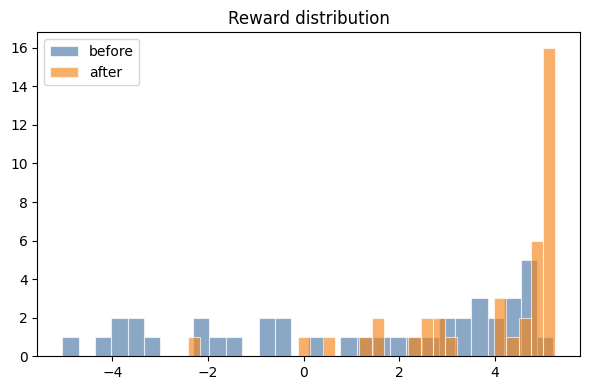

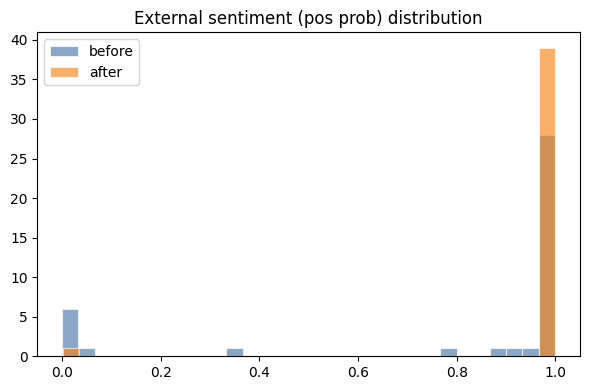

In [24]:
import matplotlib.pyplot as plt

def plot_hist(a, b, title, label_a="before", label_b="after", bins=30,
              color_a="#4C78A8", color_b="#F58518"):
    plt.figure(figsize=(6,4))
    plt.hist(a, bins=bins, alpha=0.65, label=label_a,
             color=color_a, edgecolor="white", linewidth=0.8)
    plt.hist(b, bins=bins, alpha=0.65, label=label_b,
             color=color_b, edgecolor="white", linewidth=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hist(before_reward, after_reward, "Reward distribution")
plot_hist(before_posprob, after_posprob, "External sentiment (pos prob) distribution")

## Заключение

Давайте кратко пробежимся по ключевым тезисам:

1) **Reward model** - это приближение предпочтений, она может ошибаться.  
2) **Best‑of‑N** дает быстрый выигрыш без обучения, но дорог по вычислениям.  
3) **PPO** делает выравнивание внутренним: модель сама начинает чаще выдавать тексты с высоким reward.  
4) **Reward hacking** возможен: поэтому всегда добавляйте независимые оценки и ручной просмотр.